# Chapter 13: Advanced Topics in Linear Algebra for ML

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

This final chapter brings together advanced tools that sit at the intersection of linear algebra and modern ML. These methods handle large-scale, high-dimensional, and structured data. This notebook covers:

1. **Moore-Penrose Pseudoinverse** -- solving ill-posed systems, Penrose conditions, SVD-based computation
2. **Low-Rank Approximation** -- truncated SVD, Eckart-Young-Mirsky theorem, image compression
3. **PCA** -- covariance eigenvectors, variance maximization, scree plots
4. **Spectral Decomposition** -- $A = Q\Lambda Q^T$ for symmetric matrices, spectral clustering
5. **Tensor Decompositions** -- CP decomposition, higher-order data
6. **Randomized Linear Algebra** -- random projections, Johnson-Lindenstrauss lemma, randomized SVD
7. **Matrix Manifolds** -- Stiefel manifold, optimization on constrained matrix spaces

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space
import time

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 13.1 Moore-Penrose Pseudoinverse

When $A$ is non-square or singular, $A^{-1}$ does not exist. The **pseudoinverse** $A^+$ generalizes inversion:

- **Overdetermined** ($m > n$): $A^+\mathbf{b}$ gives the least-squares solution
- **Underdetermined** ($m < n$): $A^+\mathbf{b}$ gives the minimum-norm solution

Computed via SVD: if $A = U\Sigma V^T$, then $A^+ = V\Sigma^+ U^T$ (invert nonzero singular values).

### The Four Penrose Conditions

The pseudoinverse is the unique matrix satisfying:
1. $AA^+A = A$
2. $A^+AA^+ = A^+$
3. $(AA^+)^T = AA^+$
4. $(A^+A)^T = A^+A$

In [2]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]], dtype=float)
b = np.array([1, 2, 3], dtype=float)

A_pinv = np.linalg.pinv(A)

print(f"A ({A.shape[0]}x{A.shape[1]}):\n{A}")
print(f"\nA+ ({A_pinv.shape[0]}x{A_pinv.shape[1]}):\n{A_pinv.round(4)}")

# Verify Penrose conditions
conditions = [
    ("1. A A+ A = A",       np.allclose(A @ A_pinv @ A, A)),
    ("2. A+ A A+ = A+",     np.allclose(A_pinv @ A @ A_pinv, A_pinv)),
    ("3. (A A+)^T = A A+",  np.allclose((A @ A_pinv).T, A @ A_pinv)),
    ("4. (A+ A)^T = A+ A",  np.allclose((A_pinv @ A).T, A_pinv @ A)),
]
print("\nPenrose conditions:")
for desc, ok in conditions:
    print(f"  {desc:25s} {'PASS' if ok else 'FAIL'}")

A (3x2):
[[1. 2.]
 [3. 4.]
 [5. 6.]]

A+ (2x3):
[[-1.3333 -0.3333  0.6667]
 [ 1.0833  0.3333 -0.4167]]

Penrose conditions:
  1. A A+ A = A             PASS
  2. A+ A A+ = A+           PASS
  3. (A A+)^T = A A+        PASS
  4. (A+ A)^T = A+ A        PASS


In [3]:
# Pseudoinverse via SVD (manual)
U, S, Vt = np.linalg.svd(A, full_matrices=False)
S_pinv = np.diag(1.0 / S)
A_pinv_svd = Vt.T @ S_pinv @ U.T

print(f"Pseudoinverse via SVD:\n{A_pinv_svd.round(4)}")
print(f"Matches np.linalg.pinv: {np.allclose(A_pinv, A_pinv_svd)}")

# Least-squares solution
x_pinv = A_pinv @ b
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"\nLeast-squares solution: x = {x_pinv.round(4)}")
print(f"Residual ||Ax - b|| = {np.linalg.norm(A @ x_pinv - b):.6f}")

Pseudoinverse via SVD:
[[-1.3333 -0.3333  0.6667]
 [ 1.0833  0.3333 -0.4167]]
Matches np.linalg.pinv: True

Least-squares solution: x = [-0.   0.5]
Residual ||Ax - b|| = 0.000000


In [4]:
# Underdetermined system: minimum-norm solution
A_under = np.array([[1, 1, 1]], dtype=float)
b_under = np.array([6.0])

x_min_norm = np.linalg.pinv(A_under) @ b_under
print(f"Underdetermined: A = {A_under}, b = {b_under}")
print(f"Min-norm solution: x = {x_min_norm}")
print(f"||x|| = {np.linalg.norm(x_min_norm):.4f}  (smallest among all solutions)")
print(f"Verify: Ax = {A_under @ x_min_norm}")

Underdetermined: A = [[1. 1. 1.]], b = [6.]
Min-norm solution: x = [2. 2. 2.]
||x|| = 3.4641  (smallest among all solutions)
Verify: Ax = [6.]


## 13.2 Low-Rank Matrix Approximation

The best rank-$k$ approximation is given by the truncated SVD:

$$A_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

The **Eckart-Young-Mirsky theorem** guarantees this minimizes $\|A - A_k\|_F$ among all rank-$k$ matrices.

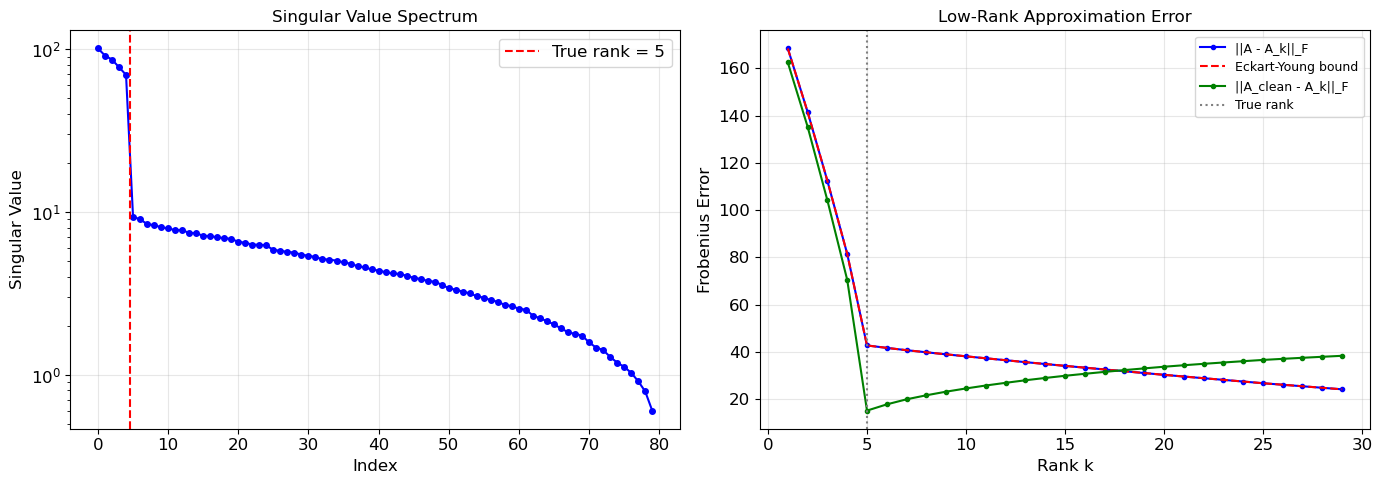

In [5]:
# Create a matrix with known rank structure + noise
np.random.seed(42)
m, n, true_rank = 100, 80, 5
U_true = np.random.randn(m, true_rank)
V_true = np.random.randn(true_rank, n)
A_clean = U_true @ V_true
A_noisy = A_clean + 0.5 * np.random.randn(m, n)

U, S, Vt = np.linalg.svd(A_noisy, full_matrices=False)

# Approximation error for different ranks
ranks = range(1, 30)
errors_frob = []
errors_to_clean = []
for k in ranks:
    A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    errors_frob.append(np.linalg.norm(A_noisy - A_k, 'fro'))
    errors_to_clean.append(np.linalg.norm(A_clean - A_k, 'fro'))

# Eckart-Young: error = sqrt(sum of discarded sigma^2)
ey_error = [np.sqrt(np.sum(S[k:]**2)) for k in ranks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(S, 'bo-', markersize=4)
ax1.axvline(true_rank - 0.5, color='red', linestyle='--', label=f'True rank = {true_rank}')
ax1.set_xlabel('Index')
ax1.set_ylabel('Singular Value')
ax1.set_title('Singular Value Spectrum', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(ranks, errors_frob, 'b.-', label='||A - A_k||_F')
ax2.plot(ranks, ey_error, 'r--', label='Eckart-Young bound')
ax2.plot(ranks, errors_to_clean, 'g.-', label='||A_clean - A_k||_F')
ax2.axvline(true_rank, color='gray', linestyle=':', label=f'True rank')
ax2.set_xlabel('Rank k')
ax2.set_ylabel('Frobenius Error')
ax2.set_title('Low-Rank Approximation Error', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

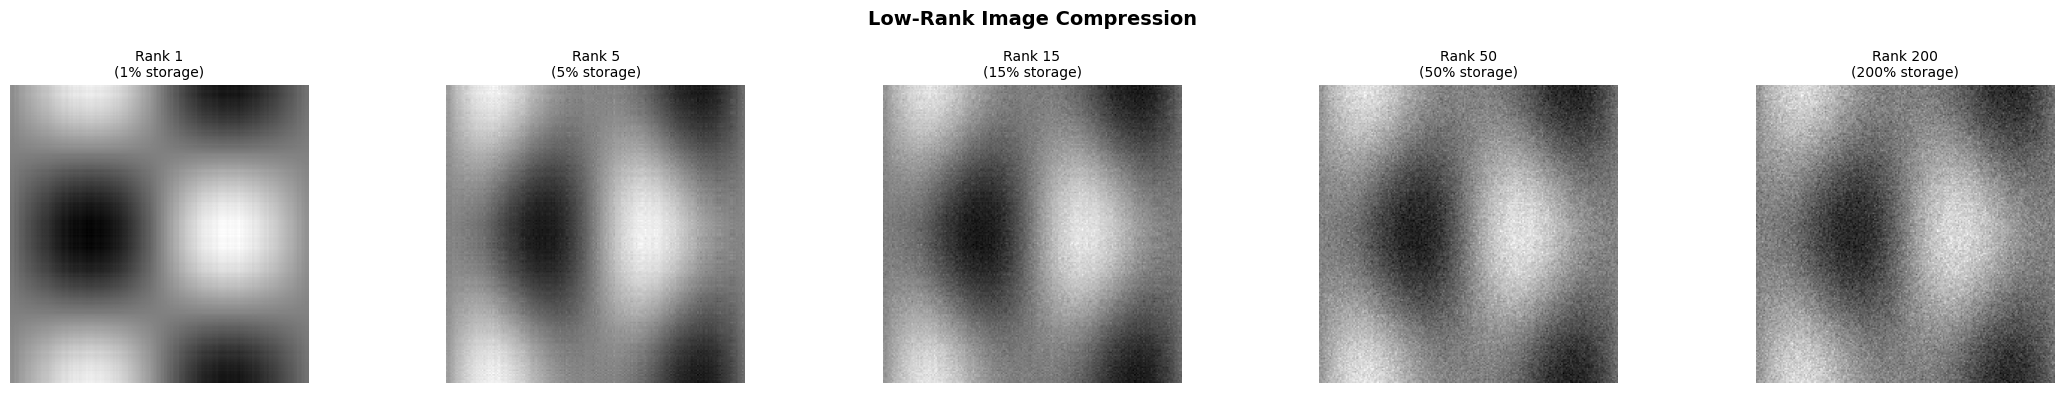

In [6]:
# Image compression via low-rank approximation
np.random.seed(7)
xg, yg = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
img = np.sin(xg) * np.cos(yg) + 0.5 * np.sin(2*xg) + 0.2 * np.random.randn(200, 200)

U_img, S_img, Vt_img = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, k in zip(axes, [1, 5, 15, 50, 200]):
    img_k = U_img[:, :k] @ np.diag(S_img[:k]) @ Vt_img[:k, :]
    compression = (k * (200 + 200 + 1)) / (200 * 200) * 100
    ax.imshow(img_k, cmap='gray')
    ax.set_title(f'Rank {k}\n({compression:.0f}% storage)', fontsize=10)
    ax.axis('off')

plt.suptitle('Low-Rank Image Compression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13.3 Principal Component Analysis (PCA)

PCA finds the orthogonal directions of maximum variance in data. The principal components are the eigenvectors of the covariance matrix $C = \frac{1}{n-1}X^TX$.

Steps:
1. Center the data (subtract mean)
2. Compute covariance matrix (or use SVD directly)
3. Eigenvectors = principal directions; eigenvalues = variance along each
4. Project data onto top-$k$ components

In [7]:
# Generate correlated 3D data
np.random.seed(42)
n_samples = 300
t = np.random.randn(n_samples)
data_3d = np.column_stack([
    2*t + 0.3*np.random.randn(n_samples),
    t + 0.3*np.random.randn(n_samples),
    0.5*t + 0.3*np.random.randn(n_samples)
])

# PCA from scratch
X_centered = data_3d - data_3d.mean(axis=0)
C = np.cov(X_centered.T)
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

explained_ratio = eigvals / eigvals.sum() * 100

print(f"Eigenvalues (variance): {eigvals.round(4)}")
print(f"Explained variance:     {explained_ratio.round(1)}%")
print(f"Cumulative:             {np.cumsum(explained_ratio).round(1)}%")
print(f"\nPrincipal components:\n{eigvecs.round(4)}")

Eigenvalues (variance): [5.1189 0.093  0.0899]
Explained variance:     [96.6  1.8  1.7]%
Cumulative:             [ 96.6  98.3 100. ]%

Principal components:
[[-0.8717  0.3524 -0.3405]
 [-0.4336 -0.2312  0.8709]
 [-0.2282 -0.9068 -0.3544]]


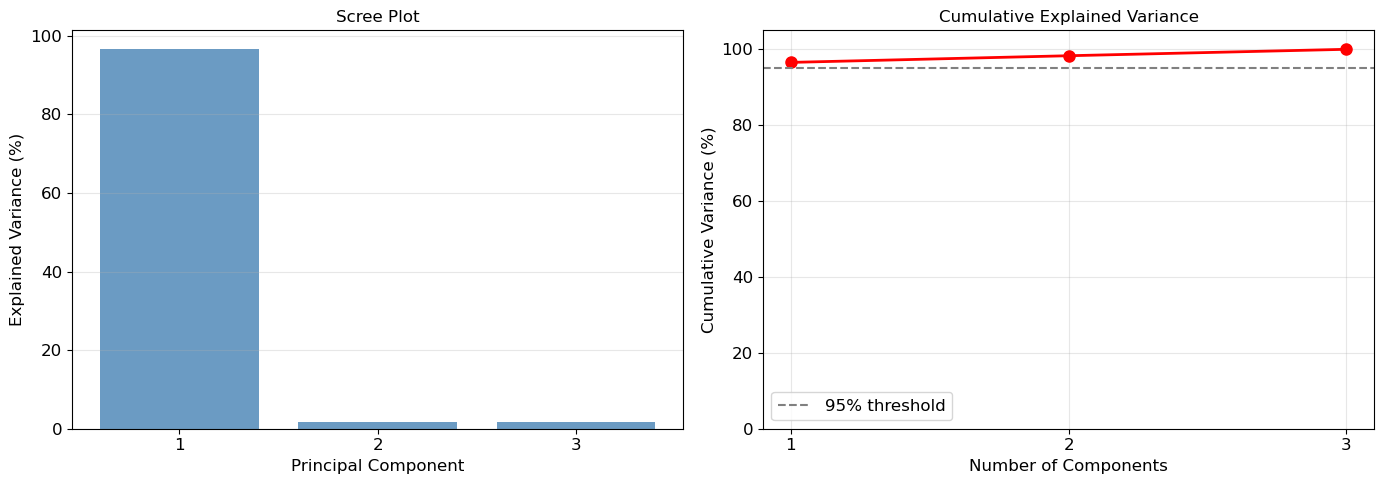

In [8]:
# Scree plot + cumulative variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 4), explained_ratio, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot', fontsize=12)
ax1.set_xticks([1, 2, 3])
ax1.grid(True, alpha=0.3, axis='y')

ax2.plot(range(1, 4), np.cumsum(explained_ratio), 'ro-', markersize=8, linewidth=2)
ax2.axhline(95, color='gray', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance', fontsize=12)
ax2.set_xticks([1, 2, 3])
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

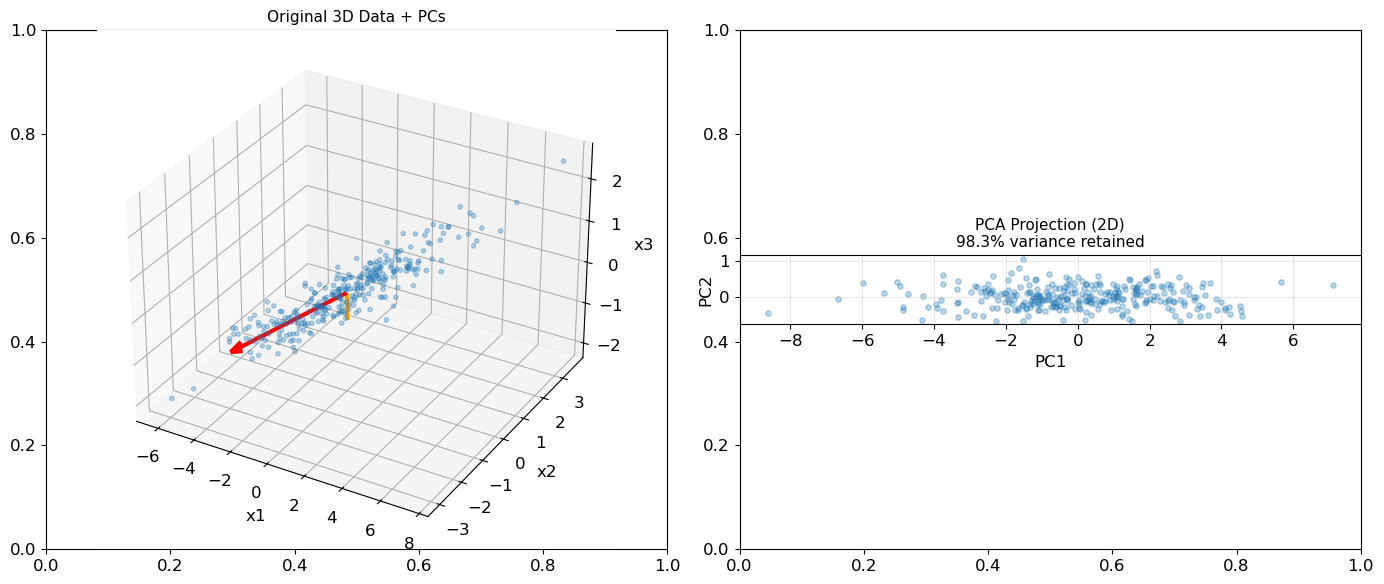

In [9]:
# Project to 2D and visualize
X_2d = X_centered @ eigvecs[:, :2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], alpha=0.3, s=10)
origin = data_3d.mean(axis=0)
for i in range(2):
    direction = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2
    ax1.quiver(*origin, *direction, color=['red', 'orange'][i], linewidth=3,
              arrow_length_ratio=0.1)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('x3')
ax1.set_title('Original 3D Data + PCs', fontsize=11)

# Projected 2D
ax2 = fig.add_subplot(122)
ax2.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=15)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title(f'PCA Projection (2D)\n{np.sum(explained_ratio[:2]):.1f}% variance retained', fontsize=11)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13.4 Spectral Decomposition

A symmetric matrix $A = A^T$ admits $A = Q\Lambda Q^T$, where $Q$ is orthogonal (eigenvectors) and $\Lambda$ is diagonal (real eigenvalues). This is the spectral theorem.

### Spectral Clustering (Conceptual)

The graph Laplacian $L = D - W$ is symmetric. Its smallest eigenvectors reveal cluster structure.

In [10]:
# Spectral decomposition of a symmetric matrix
A_sym = np.array([[2, 1],
                  [1, 2]], dtype=float)

eigvals_s, Q = np.linalg.eigh(A_sym)
Lambda = np.diag(eigvals_s)

print(f"A =\n{A_sym}")
print(f"\nEigenvalues: {eigvals_s}")
print(f"Q (eigenvectors) =\n{Q.round(4)}")
print(f"\nQ Lambda Q^T =\n{(Q @ Lambda @ Q.T).round(4)}")
print(f"Matches A? {np.allclose(Q @ Lambda @ Q.T, A_sym)}")
print(f"Q^T Q = I? {np.allclose(Q.T @ Q, np.eye(2))}")

A =
[[2. 1.]
 [1. 2.]]

Eigenvalues: [1. 3.]
Q (eigenvectors) =
[[-0.7071  0.7071]
 [ 0.7071  0.7071]]

Q Lambda Q^T =
[[2. 1.]
 [1. 2.]]
Matches A? True
Q^T Q = I? True


In [11]:
# Spectral clustering on a simple graph
# Two clusters of 4 nodes each, weakly connected
W = np.array([
    [0, 1, 1, 0.8, 0, 0, 0, 0],
    [1, 0, 1, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0.1, 0, 0, 0],
    [0.8, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0.1, 0, 0, 1, 1, 0.9],
    [0, 0, 0, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0.9, 1, 1, 0],
])
D = np.diag(W.sum(axis=1))
L = D - W

eigvals_L, eigvecs_L = np.linalg.eigh(L)
fiedler = eigvecs_L[:, 1]  # second smallest eigenvector

print(f"Laplacian eigenvalues: {eigvals_L.round(4)}")
print(f"Fiedler vector: {fiedler.round(4)}")
clusters = (fiedler > 0).astype(int)
print(f"Cluster assignments: {clusters}")
print(f"Cluster 0: nodes {np.where(clusters == 0)[0]}")
print(f"Cluster 1: nodes {np.where(clusters == 1)[0]}")

Laplacian eigenvalues: [-0.      0.0481  3.6     3.8316  4.      4.      4.      4.1202]
Fiedler vector: [-0.3578 -0.3578 -0.3406 -0.3578  0.3401  0.3578  0.3578  0.3582]
Cluster assignments: [0 0 0 0 1 1 1 1]
Cluster 0: nodes [0 1 2 3]
Cluster 1: nodes [4 5 6 7]


## 13.5 Tensor Decompositions

Tensors are multi-dimensional arrays (order > 2). The **CP decomposition** approximates a tensor as a sum of rank-1 tensors:

$$\mathcal{T} \approx \sum_{r=1}^R \mathbf{a}_r \circ \mathbf{b}_r \circ \mathbf{c}_r$$

We demonstrate using NumPy (without specialized tensor libraries).

In [12]:
# Create a rank-2 tensor from known factors
np.random.seed(42)
I, J, K = 10, 8, 6
R_true = 2

a1, a2 = np.random.randn(I), np.random.randn(I)
b1, b2 = np.random.randn(J), np.random.randn(J)
c1, c2 = np.random.randn(K), np.random.randn(K)

# Construct tensor as sum of outer products
T = np.einsum('i,j,k->ijk', a1, b1, c1) + np.einsum('i,j,k->ijk', a2, b2, c2)
T_noisy = T + 0.1 * np.random.randn(I, J, K)

print(f"Tensor shape: {T.shape}")
print(f"True rank: {R_true}")
print(f"Total entries: {T.size}")
print(f"CP storage (rank-2): {R_true * (I + J + K)} entries")
print(f"Compression ratio: {T.size / (R_true * (I + J + K)):.1f}x")

Tensor shape: (10, 8, 6)
True rank: 2
Total entries: 480
CP storage (rank-2): 48 entries
Compression ratio: 10.0x


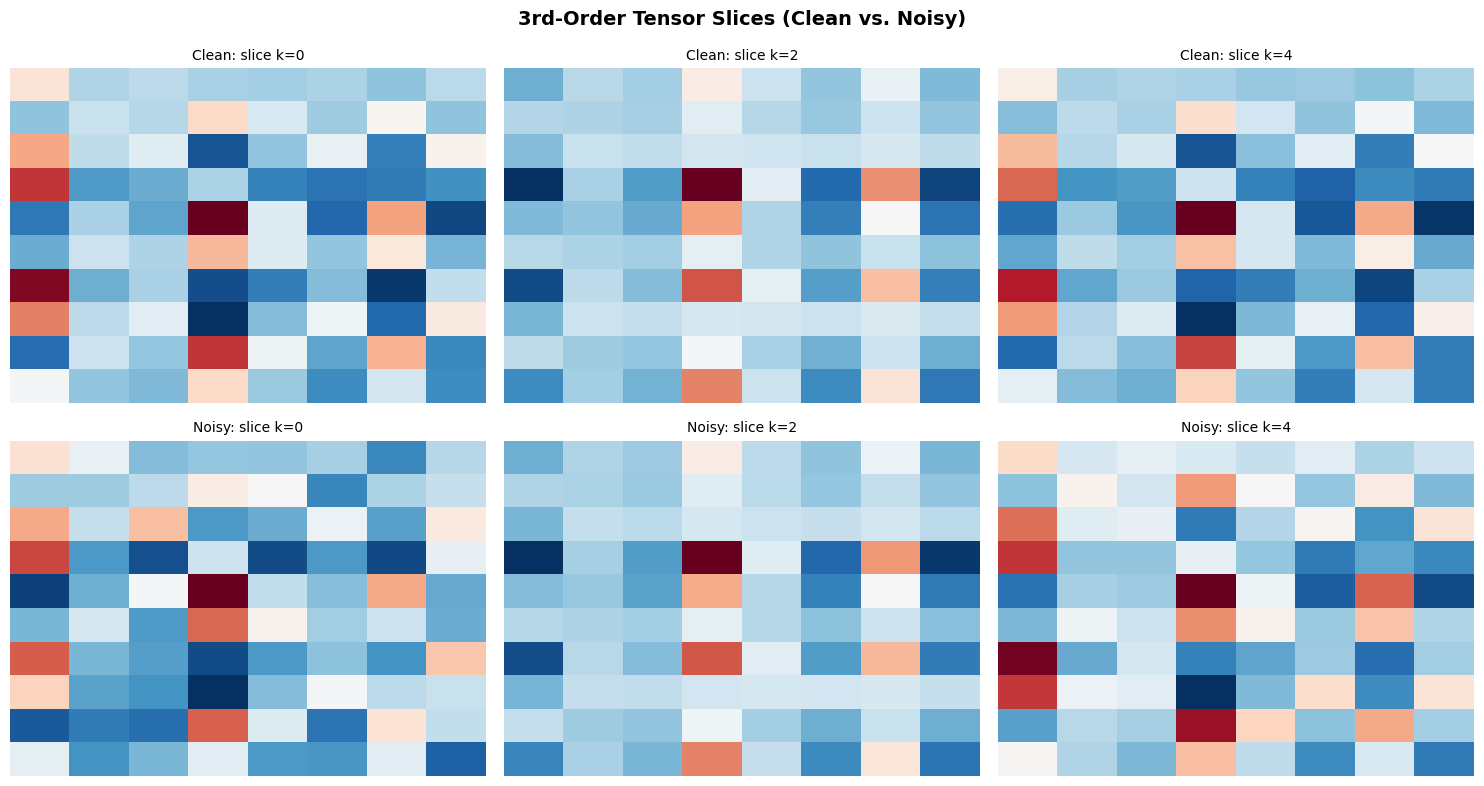

In [13]:
# Visualize tensor slices
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes[0]):
    ax.imshow(T[:, :, i*2], cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Clean: slice k={i*2}', fontsize=10)
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(T_noisy[:, :, i*2], cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Noisy: slice k={i*2}', fontsize=10)
    ax.axis('off')

plt.suptitle('3rd-Order Tensor Slices (Clean vs. Noisy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Mode-1 unfolding and SVD-based analysis
# Mode-1 unfolding: reshape T(I, J, K) -> (I, J*K)
T_unfold1 = T_noisy.reshape(I, J * K)

U_t, S_t, Vt_t = np.linalg.svd(T_unfold1, full_matrices=False)

print(f"Mode-1 unfolding shape: {T_unfold1.shape}")
print(f"Singular values: {S_t[:6].round(4)}")
print(f"First 2 capture {np.sum(S_t[:2]**2)/np.sum(S_t**2)*100:.1f}% of energy")
print(f"\nThe sharp drop after index 2 confirms the tensor has approximately rank 2.")

Mode-1 unfolding shape: (10, 48)
Singular values: [24.5313 10.2278  0.8849  0.7857  0.6748  0.6183]
First 2 capture 99.5% of energy

The sharp drop after index 2 confirms the tensor has approximately rank 2.


## 13.6 Randomized Linear Algebra

For very large matrices, exact SVD is expensive. **Randomized methods** use random projections to approximate the dominant singular vectors at much lower cost.

### Johnson-Lindenstrauss Lemma

$n$ points in $\mathbb{R}^d$ can be projected to $k = O(\log n / \epsilon^2)$ dimensions while preserving pairwise distances within $(1 \pm \epsilon)$.

In [15]:
# Johnson-Lindenstrauss: random projection preserves distances
np.random.seed(42)
n_points, d_orig = 200, 1000
X_high = np.random.randn(n_points, d_orig)

# Compute original pairwise distances (sample)
from itertools import combinations
pairs = list(combinations(range(min(50, n_points)), 2))
orig_dists = [np.linalg.norm(X_high[i] - X_high[j]) for i, j in pairs]

# Project to different dimensions
target_dims = [10, 50, 100, 200, 500]
distortion_stats = []

for k in target_dims:
    R = np.random.randn(d_orig, k) / np.sqrt(k)
    X_proj = X_high @ R
    proj_dists = [np.linalg.norm(X_proj[i] - X_proj[j]) for i, j in pairs]
    ratios = np.array(proj_dists) / np.array(orig_dists)
    distortion_stats.append((k, np.mean(np.abs(ratios - 1)), np.std(ratios)))

print(f"{'Target dim':>12s} {'Mean distortion':>16s} {'Std':>8s}")
print("-" * 40)
for k, mean_d, std_d in distortion_stats:
    print(f"{k:12d} {mean_d:16.4f} {std_d:8.4f}")
print(f"\nHigher target dimension => lower distortion (JL guarantee).")

  Target dim  Mean distortion      Std
----------------------------------------
          10           0.1787   0.2171
          50           0.0874   0.1067
         100           0.0576   0.0715
         200           0.0368   0.0457
         500           0.0252   0.0319

Higher target dimension => lower distortion (JL guarantee).


In [16]:
# Randomized SVD
def randomized_svd(A, k, oversampling=10):
    """Approximate rank-k SVD using random projection."""
    m, n = A.shape
    # Step 1: Random projection
    Omega = np.random.randn(n, k + oversampling)
    Y = A @ Omega
    # Step 2: QR of projected matrix
    Q, _ = np.linalg.qr(Y)
    # Step 3: SVD of small matrix
    B = Q.T @ A
    U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)
    U_approx = Q @ U_b
    return U_approx[:, :k], S_b[:k], Vt_b[:k, :]

# Compare exact vs randomized SVD on a large matrix
np.random.seed(42)
m, n = 500, 400
A_large = np.random.randn(m, 5) @ np.random.randn(5, n) + 0.1 * np.random.randn(m, n)

k = 5
t0 = time.time()
U_exact, S_exact, Vt_exact = np.linalg.svd(A_large, full_matrices=False)
time_exact = time.time() - t0

t0 = time.time()
U_rand, S_rand, Vt_rand = randomized_svd(A_large, k)
time_rand = time.time() - t0

# Reconstruction error
A_k_exact = U_exact[:, :k] @ np.diag(S_exact[:k]) @ Vt_exact[:k, :]
A_k_rand = U_rand @ np.diag(S_rand) @ Vt_rand

print(f"Matrix size: {m}x{n}")
print(f"Target rank: {k}")
print(f"\nExact SVD:  time = {time_exact:.4f}s, error = {np.linalg.norm(A_large - A_k_exact, 'fro'):.4f}")
print(f"Random SVD: time = {time_rand:.4f}s, error = {np.linalg.norm(A_large - A_k_rand, 'fro'):.4f}")
print(f"\nSingular values (exact):  {S_exact[:k].round(4)}")
print(f"Singular values (random): {S_rand.round(4)}")

Matrix size: 500x400
Target rank: 5

Exact SVD:  time = 0.0404s, error = 44.2284
Random SVD: time = 0.0045s, error = 58.3374

Singular values (exact):  [485.9663 464.4158 443.3579 428.026  403.2026]
Singular values (random): [485.736  464.1793 443.1075 427.6297 402.6534]


## 13.7 Matrix Manifolds and Optimization

Some optimization problems require the solution to lie on a **manifold** (e.g., orthogonal matrices, low-rank matrices). Standard gradient descent does not respect these constraints. **Riemannian optimization** projects gradients onto the tangent space of the manifold.

### Optimization on the Stiefel Manifold

The Stiefel manifold $\text{St}(n, p)$ is the set of $n \times p$ matrices with orthonormal columns: $\{X \in \mathbb{R}^{n \times p} \mid X^TX = I_p\}$.

In [17]:
def project_to_stiefel(X):
    """Project X onto the Stiefel manifold via polar decomposition."""
    U, _, Vt = np.linalg.svd(X, full_matrices=False)
    return U @ Vt

def stiefel_gradient(X, grad):
    """Project Euclidean gradient onto tangent space of Stiefel manifold."""
    return grad - X @ (X.T @ grad + grad.T @ X) / 2

# Example: minimize f(X) = -trace(X^T A X) subject to X^T X = I
# Solution: X = eigenvectors of A corresponding to largest eigenvalues
np.random.seed(42)
n, p = 5, 2
A_spd = np.random.randn(n, n)
A_spd = A_spd.T @ A_spd  # symmetric positive definite

# Initialize on manifold
X = project_to_stiefel(np.random.randn(n, p))

lr = 0.01
losses = []
for _ in range(200):
    loss = -np.trace(X.T @ A_spd @ X)
    losses.append(loss)
    grad_euc = -2 * A_spd @ X  # Euclidean gradient
    grad_riem = stiefel_gradient(X, grad_euc)  # Riemannian gradient
    X = X - lr * grad_riem
    X = project_to_stiefel(X)  # retraction: stay on manifold

# True solution: top-2 eigenvectors
eigvals_A, eigvecs_A = np.linalg.eigh(A_spd)
X_true = eigvecs_A[:, -p:]

print(f"Optimization on Stiefel manifold: min -trace(X^T A X), X^T X = I")
print(f"\nFinal loss: {losses[-1]:.4f}")
print(f"Optimal loss (from eigendecomposition): {-np.sum(eigvals_A[-p:]):.4f}")
print(f"X^T X = I? {np.allclose(X.T @ X, np.eye(p), atol=1e-6)}")

Optimization on Stiefel manifold: min -trace(X^T A X), X^T X = I

Final loss: -17.8772
Optimal loss (from eigendecomposition): -17.8778
X^T X = I? True


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_23648\3016001268.py:5: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Objective: $-\mathrm{trace}(X^TAX)$')


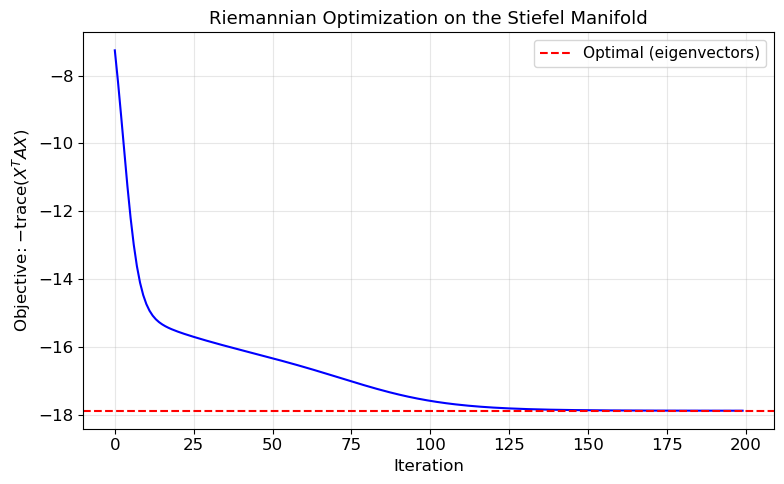

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses, 'b-', linewidth=1.5)
ax.axhline(-np.sum(eigvals_A[-p:]), color='red', linestyle='--', label='Optimal (eigenvectors)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective: $-\mathrm{trace}(X^TAX)$')
ax.set_title('Riemannian Optimization on the Stiefel Manifold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13.8 Summary: Advanced Tools at a Glance

| Tool | What It Does | ML Application |
|------|-------------|----------------|
| Pseudoinverse $A^+$ | Solves ill-posed systems | Regression, collaborative filtering |
| Low-rank approx. | Compresses matrices | Image compression, denoising |
| PCA | Finds variance-maximizing projections | Dimensionality reduction, visualization |
| Spectral decomposition | Diagonalizes symmetric matrices | Spectral clustering, graph analysis |
| Tensor decomposition | Factorizes multi-way arrays | Video analysis, recommender systems |
| Randomized SVD | Fast approximate SVD | Big data PCA, NLP |
| Matrix manifolds | Constrained optimization | Neural net compression, robust PCA |